In [1]:
import pandas as pd

dataset_path = r"spotify_dataset\spotify_top_1000_tracks.csv"

df = pd.read_csv(dataset_path, encoding="utf-8")

print("Dataset loaded!")
print(df.head(3))

Dataset loaded!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min  
0      3.869767  
1      3.840883  
2      3.182667  


In [2]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

print("Dataset loaded and basic preprocessing complete!")
print(df.head(3))

Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [3]:
import numpy as np

df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

df['year'] = df['year'].fillna(0).astype(int)

cols_to_drop = ['spotify_url', 'id', 'release_date']
df = df.drop(columns=cols_to_drop, errors='ignore')

tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels)

df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("Data cleaning complete")
print(len(df))

Data cleaning complete
971


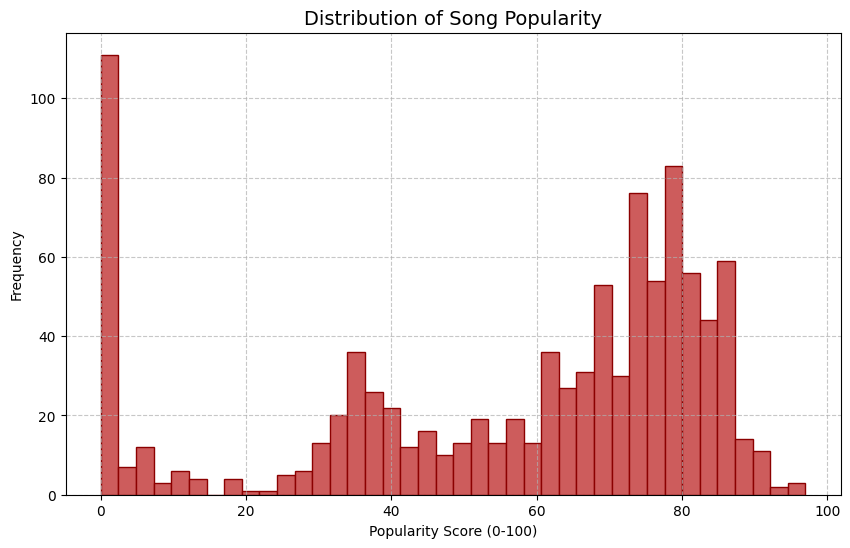

In [5]:
import matplotlib.pyplot as plt 
 
plt.figure(figsize=(10, 6)) 
plt.hist(df['popularity'], bins=40, color='indianred', 
edgecolor='darkred') 
plt.title('Distribution of Song Popularity', fontsize=14) 
plt.xlabel('Popularity Score (0-100)') 
plt.ylabel('Frequency') 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()

C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_23076\3212195994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


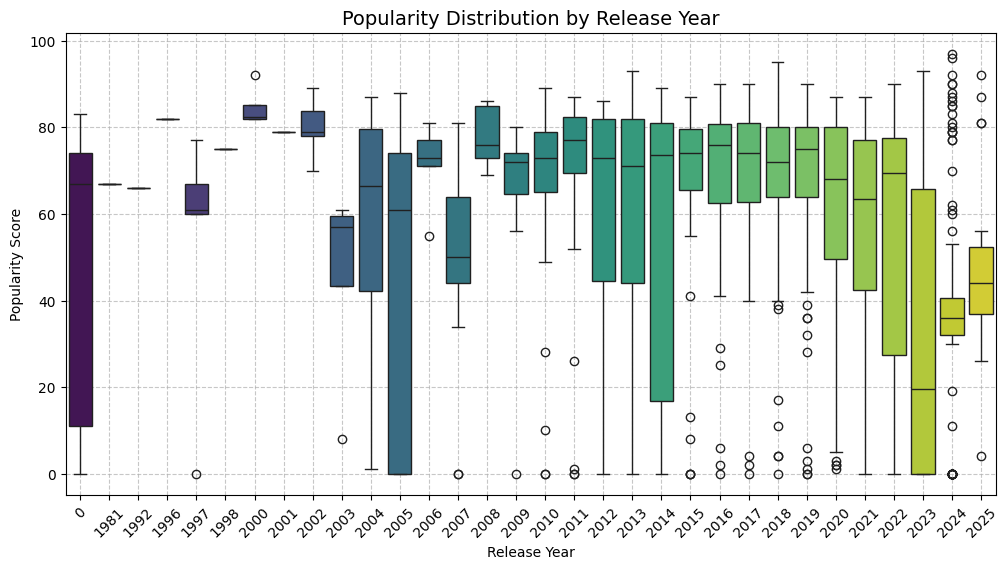

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(12, 6)) 
sns.boxplot(x='year', y='popularity', data=df, palette='viridis') 
plt.title('Popularity Distribution by Release Year', fontsize=14) 
plt.xlabel('Release Year') 
plt.ylabel('Popularity Score') 
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()

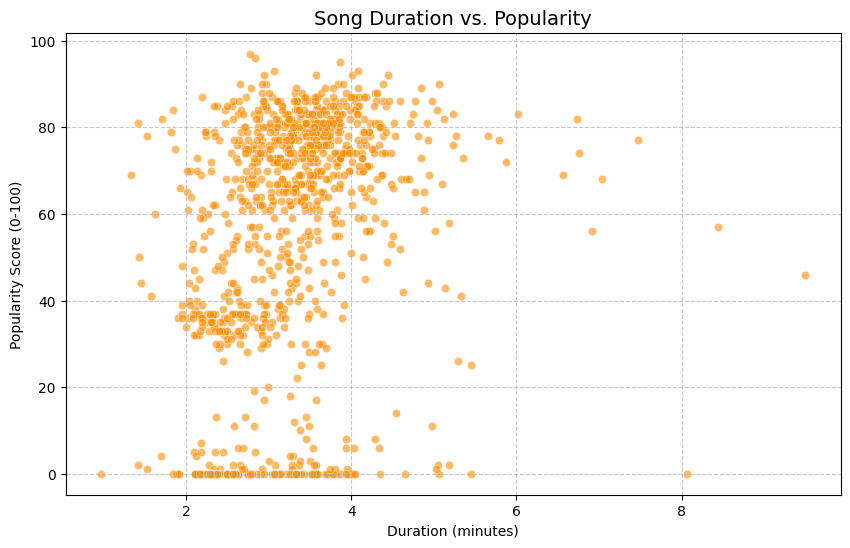

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df,
    alpha=0.6,
    color='darkorange'
)

plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show() 

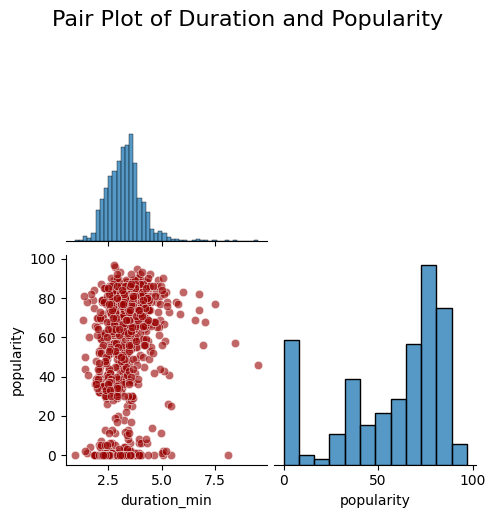

In [11]:
import matplotlib.pyplot as plt 
import seaborn as sns 
# Using only the confirmed numerical columns: 'duration_min' and 'popularity' 
key_features = ['duration_min', 'popularity'] 
# We use the simplified sns.pairplot function
sns.pairplot( 
    df[key_features],  
    diag_kind='hist',  
    corner=True,  
    plot_kws={'alpha': 0.6, 'color': '#990000'} 
) 
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16) 
plt.show()

<Figure size 800x800 with 0 Axes>

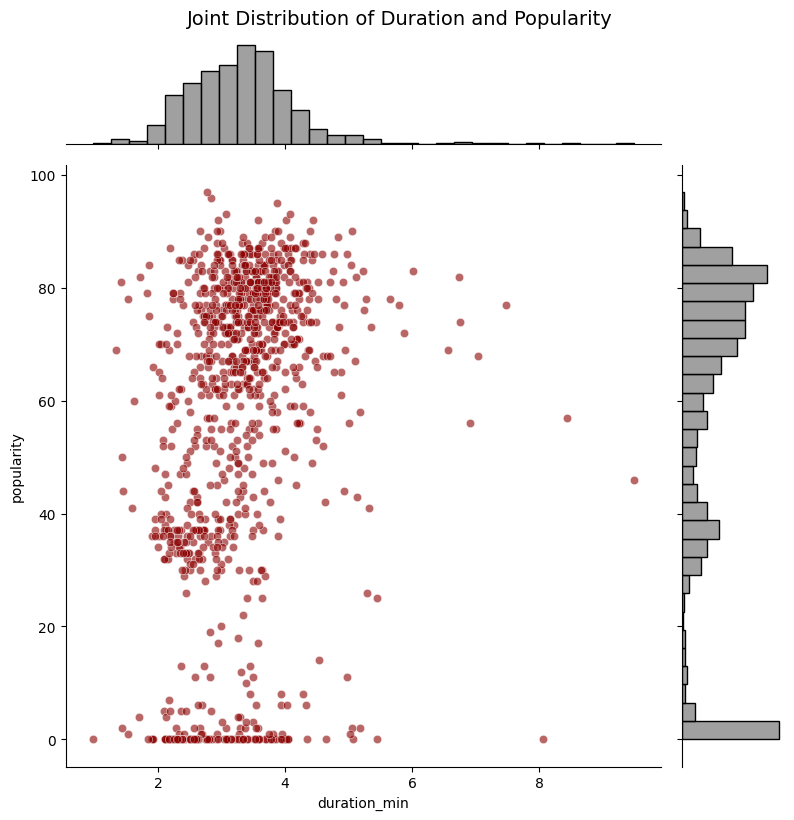

In [15]:
import matplotlib.pyplot as plt 
import seaborn as sns 
 
plt.figure(figsize=(8, 8)) 
sns.jointplot( 
    x='duration_min',  
    y='popularity',  
    data=df,  
    kind='scatter',  # Use 'scatter' for the central plot type 
    height=8,        # Controls the overall size of the plot 
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'}, 
    joint_kws={'alpha': 0.6, 'color': 'darkred'} 
) 
 
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, 
fontsize=14) 
plt.show()

In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# Step 1: Load Dataset
csv_file = "spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_file)

# Step 2: Data Preparation
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# Step 3: Initialize Figure
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)

line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')

ax.set_title("Evolution of Track Popularity Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Average Popularity")
ax.legend()

plt.tight_layout()

# Step 4: Animation Function
def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# Step 5: Create Animation
ani = FuncAnimation(
    fig,
    animate,
    frames=len(yearly_popularity) + 1,
    interval=100,
    repeat=False
)

# Step 6: Save GIF
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))

print("GIF saved at:", gif_path)

# Step 7: Open GIF
webbrowser.open("file://" + gif_path)

plt.close(fig)

GIF saved at: c:\Users\RG Gamas\Lab7_Data_Visualization\yearly_popularity_trend.gif


In [48]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
student_name = "Robert Gabriel A. Gamas" 
student_id = "TUPM-25-0925"
 
id_num = int(student_id[-3:]) 
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) 
% 256:02x}" 
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) 
% 256:02x}" 

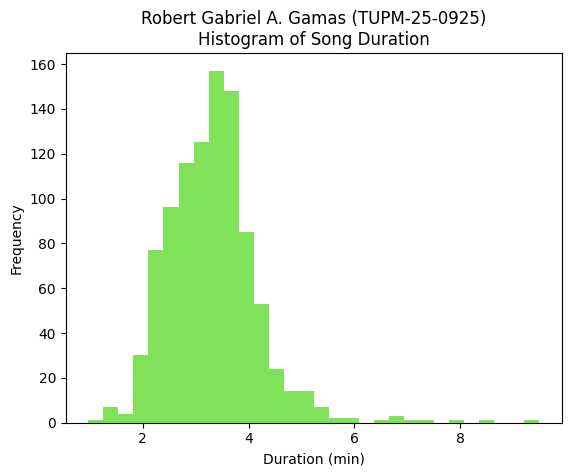

In [49]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Frequency') 
plt.show()

C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\789271490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


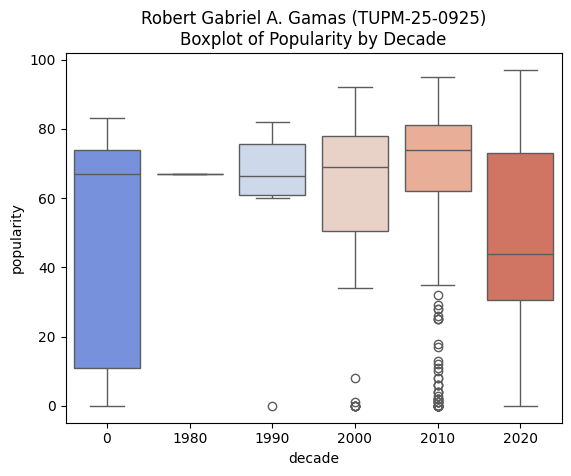

In [64]:
df['decade'] = (df['year'] // 10) * 10 
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade") 
plt.show()

C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\887992834.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


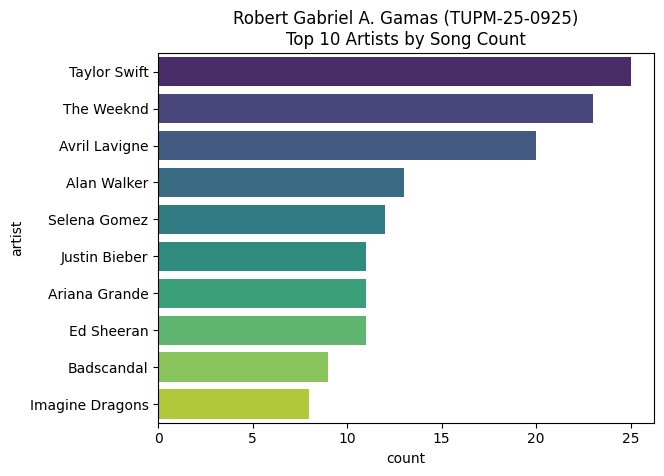

In [65]:
sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis') 
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count") 
plt.show()

C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\3160744663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')
C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\3160744663.py:1: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')


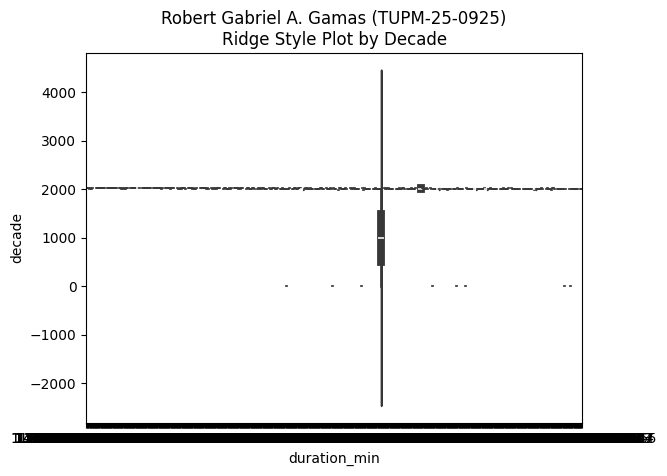

In [66]:
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width') 
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade") 
plt.show()

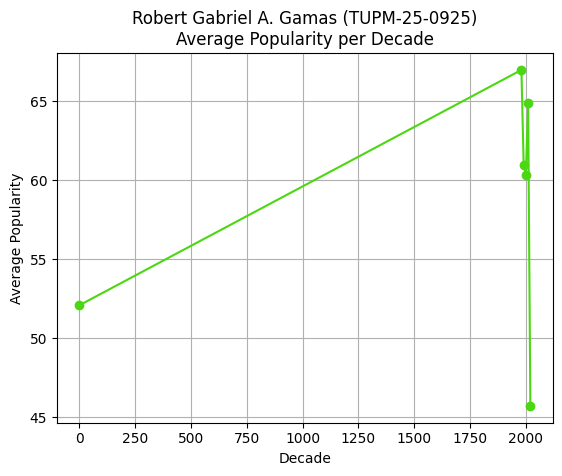

In [67]:
avg_pop = df.groupby('decade')['popularity'].mean() 
avg_pop.plot(kind='line', color=color1, marker='o') 
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade") 
plt.xlabel('Decade') 
plt.ylabel('Average Popularity') 
plt.grid(True) 
plt.show()

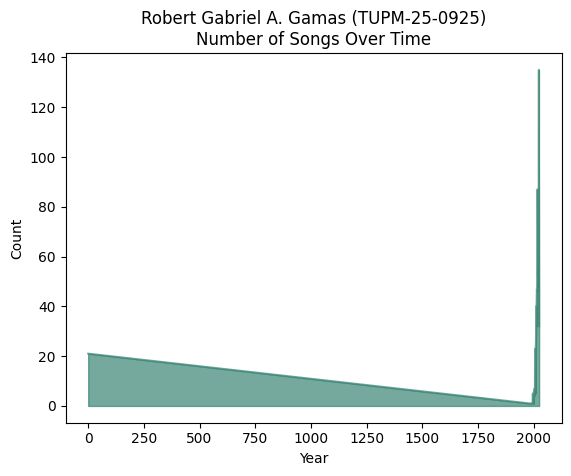

In [73]:
count_by_year = df['year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

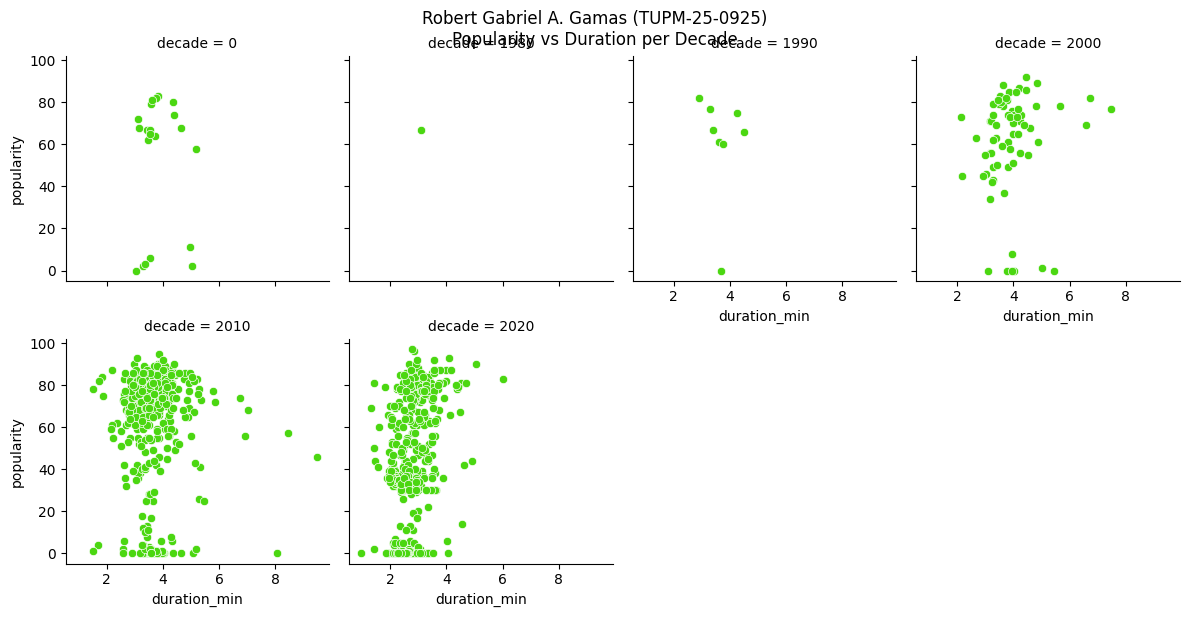

In [75]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3) 
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', 
color=color1) 
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02) 
plt.show()

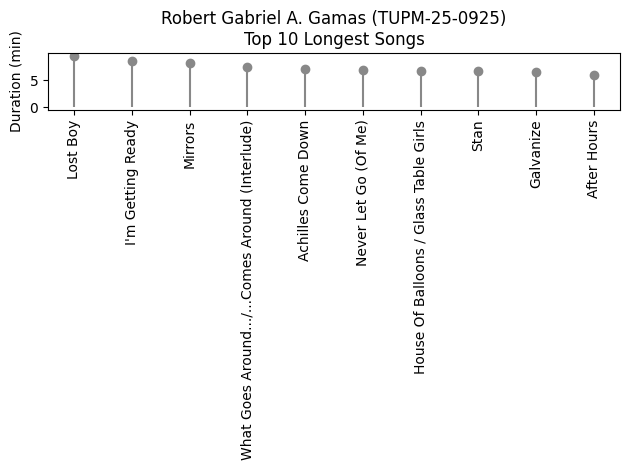

In [76]:
longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show()

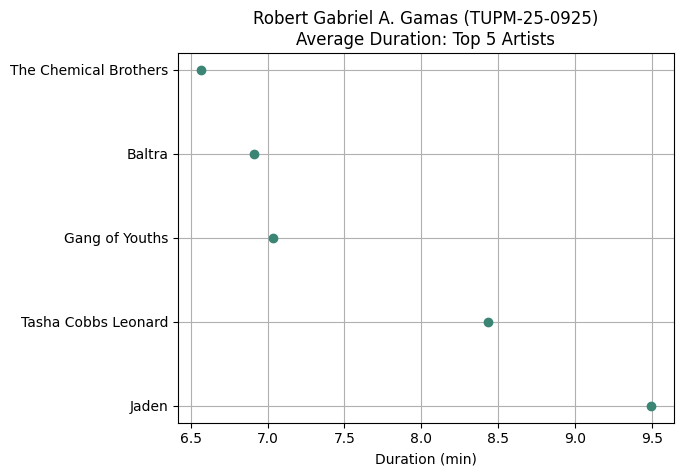

In [78]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show()

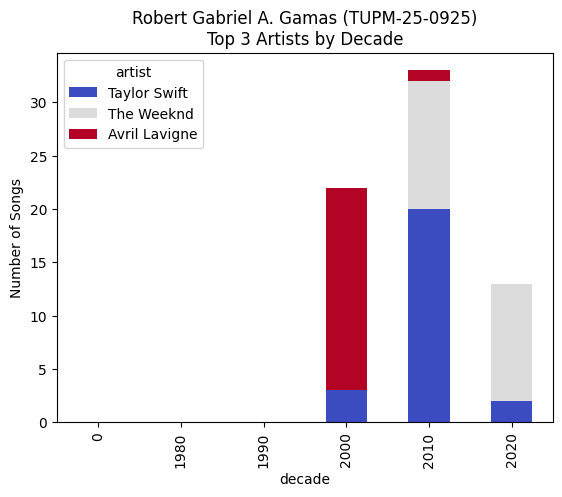

In [79]:
crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show()

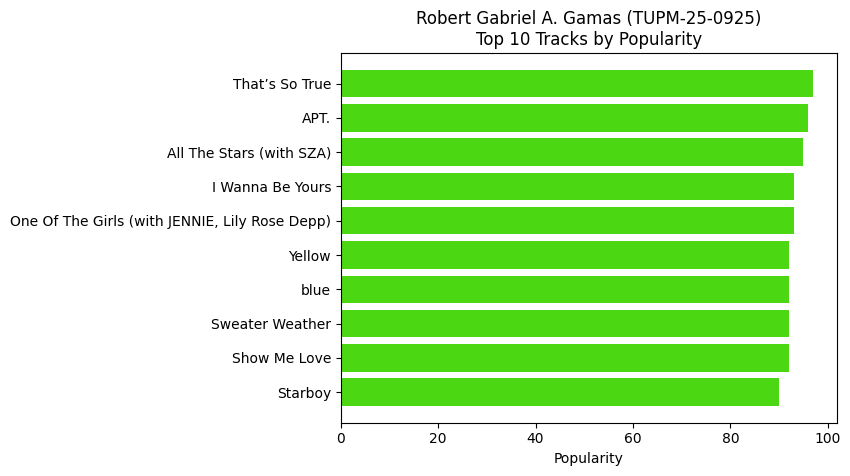

In [80]:
top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show()

C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\1182823657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\1182823657.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


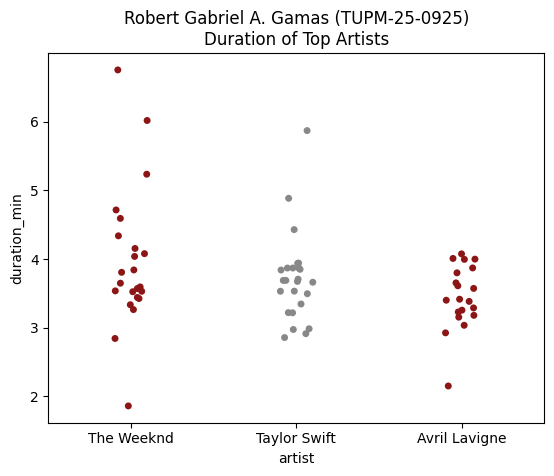

In [81]:
top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show()

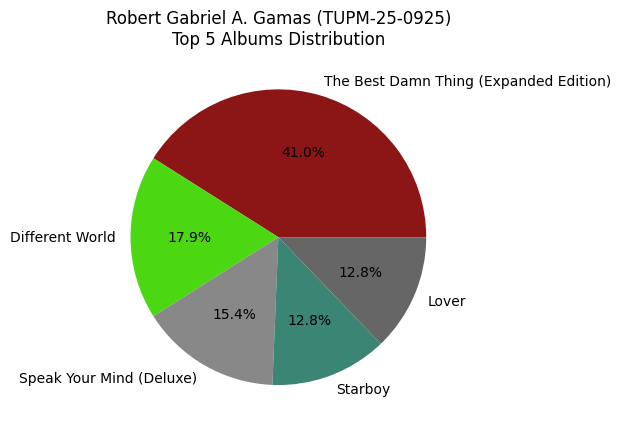

In [82]:
top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', 
colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show()

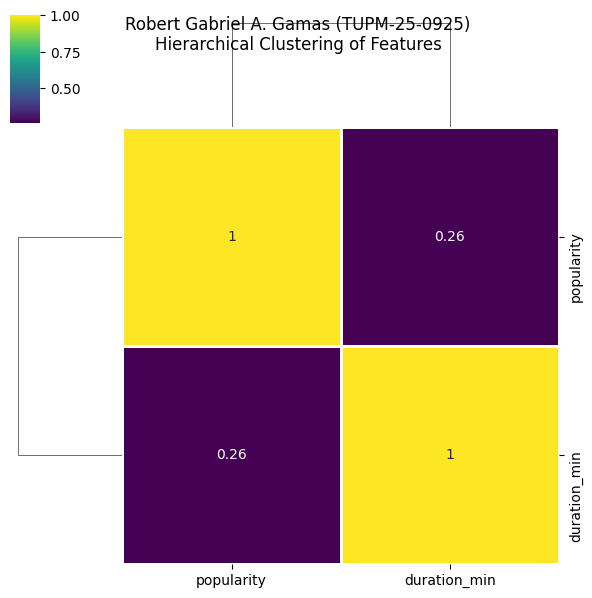

In [11]:
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', 
linewidths=.75, figsize=(6, 6))

plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features")
plt.show()

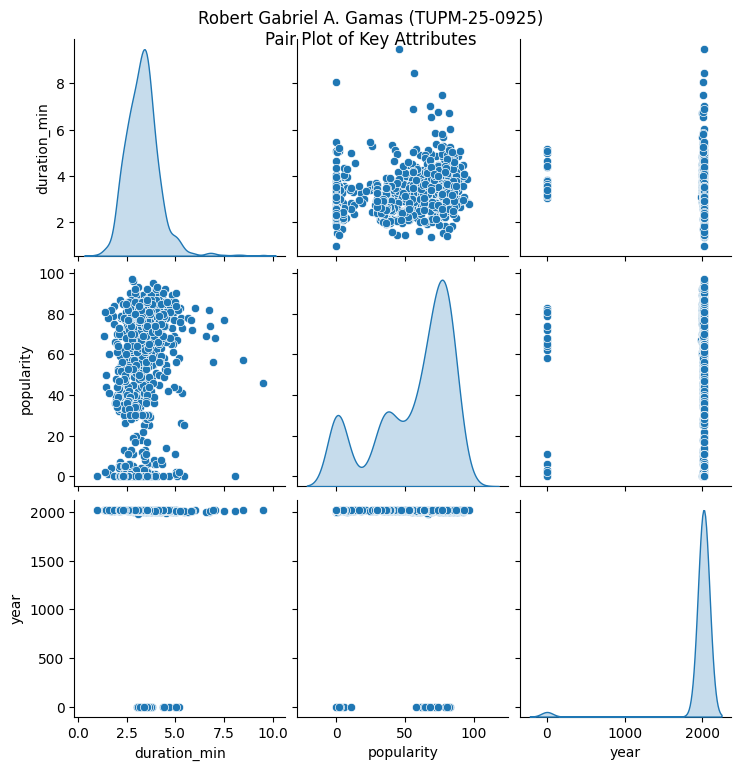

In [99]:
sns.pairplot(df[['duration_min', 'popularity', 'year']], diag_kind='kde') 
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02) 
plt.show()

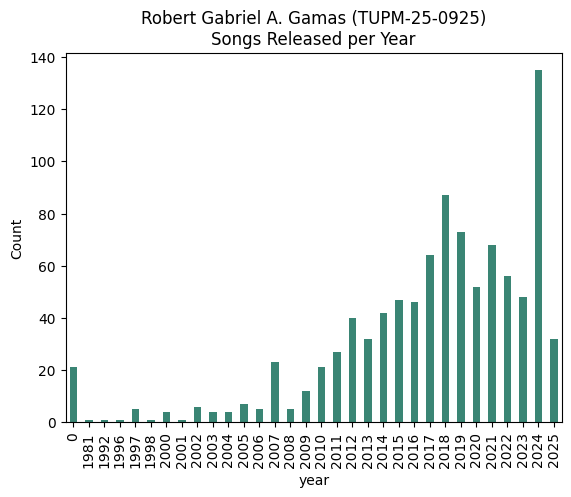

In [101]:
df['year'].value_counts().sort_index().plot(kind='bar', color=color2) 
plt.title(f"{student_name} ({student_id})\nSongs Released per Year") 
plt.ylabel('Count') 
plt.show()

C:\Users\RG Gamas\AppData\Local\Temp\ipykernel_27928\1976752960.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


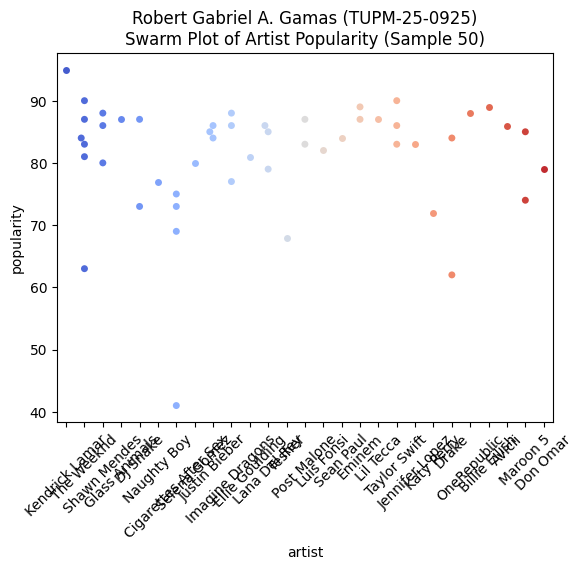

In [102]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show()

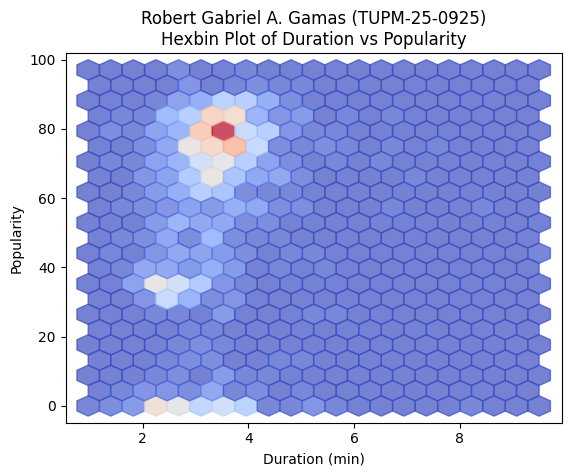

In [104]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, 
cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity") 
plt.show()

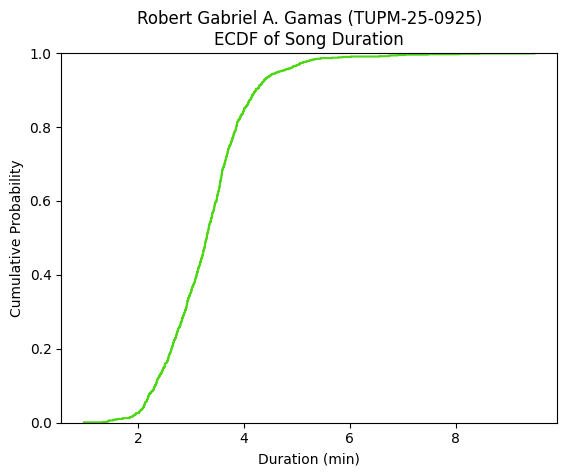

In [105]:
sns.ecdfplot(data=df, x='duration_min', color=color1) 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show()

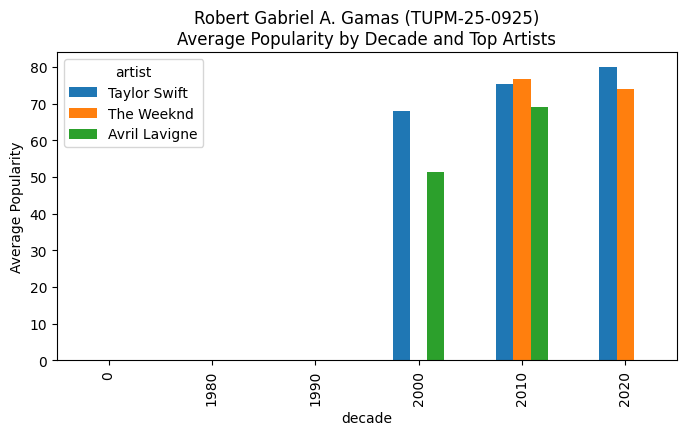

In [106]:
avg_artist_decade = df.groupby(['decade', 
'artist'])['popularity'].mean().unstack().fillna(0) 
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4)) 
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists") 
plt.ylabel('Average Popularity') 
plt.show()